**Examen Final - Clasificación de Mortalidad Hospitalaria**

Diego Andrés Burbano A.


## **1. Importar librerias necesarias para el modelo**

In [21]:
import warnings # Ignorar las warnings
warnings.filterwarnings("ignore")

#Instalación de ydata-profiling para reporte de perfilamiento de data
!pip install ydata-profiling

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, make_scorer, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from ydata_profiling import ProfileReport
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
#from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.base import clone
#from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
#from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.metrics import confusion_matrix, accuracy_score , average_precision_score, f1_score, classification_report, precision_recall_curve, auc, precision_score, recall_score, roc_auc_score, roc_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.dummy import DummyClassifier
from imblearn.ensemble import RUSBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

import os
from google.colab import drive



## **2. Carga de datos y evaluación del set de datos proporcionado**

In [3]:
# En esta celda se esta montando el drive  que tiene almacenado los datos en la ruta MyDrive/datos
drive.mount('/content/drive', force_remount=True)

# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/datos/')

Mounted at /content/drive


Se realiza una revisión preliminar del set de datos:

In [4]:
data = pd.read_csv('./data_train.csv', sep=',')
data.head()

,Unnamed: 0,age,sex,dzgroup,dzclass,num.co,scoma,avtisst,race,sps,...,dnr,dnrday,meanbp,hrt,resp,temp,crea,sod,adlsc,hospdead
0,0,62.84998,male,Lung Cancer,Cancer,0,0.0,7.000000,other,33.898438,...,no dnr,5.0,97.0,69.0,22.0,36.00000,1.199951,141.0,7.0,0
1,1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,44.0,29.000000,white,52.695312,...,NaN,NaN,43.0,112.0,34.0,34.59375,5.500000,132.0,1.0,1
2,2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,0.0,13.000000,white,20.500000,...,no dnr,17.0,70.0,88.0,28.0,37.39844,2.000000,134.0,0.0,0
3,3,42.38498,female,Lung Cancer,Cancer,2,0.0,7.000000,white,20.097656,...,no dnr,3.0,75.0,88.0,32.0,35.00000,0.799927,139.0,0.0,0
4,4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,26.0,18.666656,white,23.500000,...,no dnr,16.0,59.0,112.0,20.0,37.89844,0.799927,143.0,2.0,0


In [5]:
#Cantidad y dimensionalidad de los datos
data.shape

(9105, 27)

In [6]:
#Perfilamiento inicial de los datos
data.describe()

,Unnamed: 0,age,num.co,scoma,avtisst,sps,aps,surv2m,surv6m,hday,...,dementia,dnrday,meanbp,hrt,resp,temp,crea,sod,adlsc,hospdead
count,9105.000000,9105.000000,9105.000000,9104.000000,9023.000000,9104.000000,9104.000000,9104.000000,9104.000000,9105.000000,...,9105.000000,9075.000000,9104.000000,9104.000000,9104.000000,9104.000000,9038.000000,9104.000000,9105.000000,9105.000000
mean,4552.000000,62.650823,1.868644,12.058546,22.610928,25.525872,37.597979,0.635870,0.520096,4.400000,...,0.032510,14.582590,84.546408,97.156711,23.330294,37.103341,1.770961,137.568541,1.888272,0.259198
std,2628.531434,15.593710,1.344409,24.636694,13.233248,9.899377,19.903852,0.248175,0.253343,9.126811,...,0.177359,19.944216,27.687692,31.559292,9.573801,1.251796,1.686041,6.029326,2.003763,0.438219
min,0.000000,18.041990,0.000000,0.000000,1.000000,0.199982,0.000000,0.000000,0.000000,1.000000,...,0.000000,-88.000000,0.000000,0.000000,0.000000,31.699220,0.099991,110.000000,0.000000,0.000000
25%,2276.000000,52.797000,1.000000,0.000000,12.000000,19.000000,23.000000,0.507690,0.342957,1.000000,...,0.000000,4.000000,63.000000,72.000000,18.000000,36.195310,0.899902,134.000000,0.000000,0.000000
50%,4552.000000,64.856990,2.000000,0.000000,19.500000,23.898438,34.000000,0.715942,0.574951,1.000000,...,0.000000,9.000000,77.000000,100.000000,24.000000,36.695310,1.199951,137.000000,1.000000,0.000000
75%,6828.000000,73.998960,3.000000,9.000000,31.666656,30.199219,49.000000,0.825928,0.725952,3.000000,...,0.000000,17.000000,107.000000,120.000000,28.000000,38.195310,1.899902,141.000000,3.000000,1.000000
max,9104.000000,101.847960,9.000000,100.000000,83.000000,99.187500,143.000000,0.969971,0.947998,148.000000,...,1.000000,285.000000,195.000000,300.000000,90.000000,41.695310,21.500000,181.000000,7.073242,1.000000


In [7]:
profile = ProfileReport(data, title="Reporte de Perfilamiento", explorative=True)

In [ ]:
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

**Características del set de datos**



*   El set de datos presenta un desbalanceo favoreciendo a la clase 0 (sobrevivientes) frente a la clase 1 (paciente fallecido) la cual tiene un 26% de representatividad. Considerando el tipo de aplicación para la cual se hace el presente notebook, esto representa un problema ya que existe un sesgo natural hacia la clase negativa, la cual no es el objeto de la predicción.
*   List item



**Análisis de balance de datos en el set:**

Como se indicó en la descripción de las características del set de datos, existe un desbalanceo favoreciendo a la clase que no es el objeto de la predicción. Considerando que este modelo pretende predecir la mortalidad en centros médicos, un sesgo hacia la clase "superviviente" debe ser evitado, ya que limitaría el valor clínico del modelo.

Por esta razón, se toma la decisión de balancear el set de datos utilizando técnicas de oversampling. Esta técnica se prefiere porque no altera los registros existentes, sino que replica o sintetiza ejemplos de la clase minoritaria, preservando así la integridad del dataset original.

Se descarta el uso de imputación de datos en este contexto, ya que, tratándose de aplicaciones médicas, la creación de datos ficticios para variables críticas podría falsear la realidad clínica. Esto representaría un alto riesgo ético y metodológico, aun si mejorara artificialmente las métricas de desempeño.

Adicionalmente, para evaluar el modelo de forma justa en presencia de este desbalance, se utilizarán métricas robustas como F1-score, recall y AUC, que permiten valorar el desempeño en la predicción de la clase minoritaria con mayor precisión que la simple métrica de accuracy.

**Análisis de datos faltantes**

In [8]:
#Revisión de datos faltantes totales
print(f"Total de datos nulos en el dataset: {data.isna().sum().sum()}")

#Revisión de datos faltantes por clase
faltantes_col = data.isna().sum()
faltantes_pct = (faltantes_col / len(data)) * 100
faltantes_df = pd.DataFrame({
    'Faltantes': faltantes_col,
    'Porcentaje': faltantes_pct
}).sort_values(by="Porcentaje", ascending=False)

print(faltantes_df)

Total de datos nulos en el dataset: 261
            Faltantes  Porcentaje
avtisst            82    0.900604
crea               67    0.735859
race               42    0.461285
dnr                30    0.329489
dnrday             30    0.329489
aps                 1    0.010983
hrt                 1    0.010983
surv2m              1    0.010983
sps                 1    0.010983
resp                1    0.010983
scoma               1    0.010983
temp                1    0.010983
sod                 1    0.010983
meanbp              1    0.010983
surv6m              1    0.010983
age                 0    0.000000
Unnamed: 0          0    0.000000
num.co              0    0.000000
sex                 0    0.000000
dzclass             0    0.000000
dzgroup             0    0.000000
hday                0    0.000000
diabetes            0    0.000000
dementia            0    0.000000
ca                  0    0.000000
adlsc               0    0.000000
hospdead            0    0.000000


Encontramos un total de 261 datos faltantes

In [9]:
# Filtramos solo las filas que tienen al menos un NaN
filas_con_nulos = data[data.isna().any(axis=1)]

# Mostramos cuántas son
print("Número de filas con nulos:", len(filas_con_nulos))

# Sumamos la columna hospdead en ese subconjunto
suma_hospdead = filas_con_nulos["hospdead"].sum()

print("Suma de hospdead en esas filas:", suma_hospdead)


Número de filas con nulos: 217
Suma de hospdead en esas filas: 49


Los 261 datos faltantes se concentran en un total de 217 filas. Del total de 217 filas con datos nulos, 49 pertenecen a la clase menos dominante (hospdead = 1).

Se toma la decisión de eliminar las 217 filas por las siguientes razones:

*   Desde el punto de vista técnico, eliminar 217 filas representa un bajo volumen considerando el volumen total del dataset. Representatividad inferior al 3%.
*   Los datos a eliminar no se concentran en una única variable y el volumen de los mismos es inferior al 1% del volumen total de la misma según se ve en la revisión de datos por clase.
*   Si bien perder 49 datos positivos de la variable 'hospdead' puede afectar el recall del modelo, pero se prefiere esto para tener un dataset limpio.
*   La alternativa de imputar datos no se considera ya que por el tipo de aplicación, en este caso detección de morbilidad, la invención de datos para variables críticas implica manipular la integridad del set de datos, lo cual éticamente es un problema.

Procederemos con la eliminación en la siguiente sección del notebook.

**Análisis de datos repetidos:**

In [10]:
#Identificación de datos repetidos
print(f'Datos duplicados: {data.duplicated().sum()}')

Datos duplicados: 0


No existen datos duplicados o repetidos.

### **2.1 Pre - alistamiento del set de datos**

De acuerdo con las conclusiones presentadas en el análisis del dataset, procederemos preparar nuestro set de datos realizando las siguientes acciones sobre el mismo:
1. Eliminación de la variable 'Unnamed 0'por tratarse de una variable que no aporta a la labor de predicción por tratarse de un ID secuencial.
2. Eliminación de la variable 'dzclass': en la matriz de correlación se muestra como esta variable presenta alta relación con la variable 'dzgroup' con el fin de evitar la colinealidad.
3. Eliminación de las variables 'surv2m' y surv6m', ya que se trata de variables de predicción de supervivencia pre-calculadas (indicadores de mortalidad a 2 y 6 meses), las cuales tienen altísima correlación entre sí y probablemente con la mortalidad; por lo tanto existe el riesgo que el modelo se "apoye" en ellas y no en las variables clínicas, dando de esta manera métricas infladas pero no generalizables..  
4. Eliminación de los registros que presenten datos nulos (217 en total)

In [11]:
# Obtenemos una copia del set de datos
data_clean = data.copy()
data_clean.shape

(9105, 27)

In [13]:
# Reducción manual de la dimensionalidad - eliminación de variables seleccionadas
data_clean.drop(['Unnamed: 0', 'dzclass', 'surv2m', 'surv6m'], axis=1, inplace=True)
data_clean.head()

,age,sex,dzgroup,num.co,scoma,avtisst,race,sps,aps,hday,...,dnr,dnrday,meanbp,hrt,resp,temp,crea,sod,adlsc,hospdead
0,62.84998,male,Lung Cancer,0,0.0,7.000000,other,33.898438,20.0,1,...,no dnr,5.0,97.0,69.0,22.0,36.00000,1.199951,141.0,7.0,0
2,52.74698,female,Cirrhosis,2,0.0,13.000000,white,20.500000,45.0,4,...,no dnr,17.0,70.0,88.0,28.0,37.39844,2.000000,134.0,0.0,0
3,42.38498,female,Lung Cancer,2,0.0,7.000000,white,20.097656,19.0,1,...,no dnr,3.0,75.0,88.0,32.0,35.00000,0.799927,139.0,0.0,0
4,79.88495,female,ARF/MOSF w/Sepsis,1,26.0,18.666656,white,23.500000,30.0,3,...,no dnr,16.0,59.0,112.0,20.0,37.89844,0.799927,143.0,2.0,0
5,93.01599,male,Coma,1,55.0,5.000000,white,19.398438,27.0,1,...,no dnr,4.0,110.0,101.0,44.0,38.39844,0.699951,140.0,1.0,1


In [14]:
# Eliminación de registros con datos nulos
data_clean.dropna(inplace=True)
data_clean.shape

(8888, 23)

Se eliminan en total 217 registros o filas del set de datos

##**3. Preparación de los sets de entrenamiento**

Con el fin de evitar el data leakage dividimos nuestro set de datos limpio (data_clean) en entrenamiento (train) y prueba (test).

In [15]:
# Dividir los datos (X) y variable objetivo (y)
X = data_clean.drop('hospdead', axis=1)
y = data_clean['hospdead']

# Dividir los datos en conjuntos de entrenamiento y prueba
#Set (80% entrenamiento / 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

# Calculo de pesos modelo desbalanceado
c1 = y_train.value_counts()[0]
c2 = y_train.value_counts()[1]


## **4. Preparación y desarrollo de Pipeline de transformación de data y entrenamiento de modelo**

Dentro del proceso de transformación de datos es necesario la conversión de las variables categóricas en numéricas de la siguiente manera:

*   Categorica nominal: se aplica One-Hot Encoding a las variables 'dzgroup' y 'race', dado que no presentan un orden intrínseco.
*   Codificación ordinal: se aplica Ordinal Encoding a la variable 'ca' (con niveles clínicos: no, yes, metastatic), así como a las variables 'dnr' y 'sex', donde existe un orden lógico o binario.

Este esquema de codificación se implementa en el transformador preprocessor, que será integrado más adelante dentro del pipeline de modelado.

In [16]:
# Parámetros de preprocesamiento de los datos

# Variables categóricas por tipo de codificación
ohe_vars = ["dzgroup", "race"]
ordinal_vars = ["ca"]
dnr_vars = ["dnr"]
sex_vars = ["sex"]

# Identificar columnas numéricas (todas las demás que no son categóricas)
numeric_vars = [col for col in X_train.columns if col not in ohe_vars + ordinal_vars + dnr_vars + sex_vars]

# Definir transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(drop="first", sparse_output=False), ohe_vars),
        ("ordinal", OrdinalEncoder(), ordinal_vars),
        ("dnr", OrdinalEncoder(), dnr_vars),
        ("sex", OrdinalEncoder(categories=[["male", "female"]]), sex_vars),
        ("num", RobustScaler(), numeric_vars)
    ],
    remainder="drop"
)

A continuación se construye el pipeline, el cual integra en primer lugar el transformador preprocessing definido previamente, seguido del proceso de ajuste de balance mediante RandomUnderSampler. Finalmente, se incluye el paso classifier como un placeholder neutral, lo que asegura que el pipeline tenga esta etapa lista para ser reemplazada por los modelos que se especificarán en el param_grid durante el proceso de búsqueda con GridSearchCV.

Para el ajuste de balance se seleccionó el método RandomUnderSampler por las siguientes razones:

*   Reduce la clase mayoritaria hasta igualarla con la clase minoritaria (clase 1), manteniendo la integridad del conjunto de datos.

*   A diferencia de otros métodos, no genera datos sintéticos. Esto resulta especialmente relevante en aplicaciones clínicas, donde la creación de datos ficticios para predecir la supervivencia de un paciente puede plantear cuestionamientos éticos.

*   Se prefiere frente a RandomOverSampler, ya que este último equilibra el conjunto repitiendo instancias de la clase minoritaria, lo que puede incrementar el riesgo de overfitting.


In [17]:
# Preparacion de pipeline de transformacion

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("undersampler", RandomUnderSampler(random_state=42)),
    ("classifier", DummyClassifier())
])

In [18]:
# Diccionario de métricas
scoring_metrics = {
    'Accuracy': 'accuracy',
    'F1_Weighted': 'f1_weighted',
    'Precision_Weighted': 'precision_weighted',
    'Recall_Weighted': 'recall_weighted',
    'ROC_AUC': 'roc_auc'
}

A continuación se presentan los criterios definidos para la selección del set de algoritmos y parámetros que se utilizarán en el GridSearchCV, considerando para ello el tipo de aplicación el cual es la predicción de supervivencia de pacientes en entornos clínicos:
1. Interpretabilidad: En medicina, los profesionales clínicos y auditores deben comprender por qué un modelo genera determinadas predicciones. Por ello, se evita priorizar algoritmos de tipo 'caja negra' que, aunque puedan lograr mayor precisión, no aportan claridad sobre el proceso de decisión.
2. Balance entre sensibilidad y especificidad: Se prioriza el uso de métricas como F1-score en lugar de accuracy. En particular, la sensibilidad para la clase 1 (mortalidad) es crítica, dado que el costo de clasificar erróneamente un paciente con riesgo de muerte es significativamente mayor que clasificar erróneamente un paciente sobreviviente.
3. Generalización y estabilidad: El modelo debe mostrar un comportamiento consistente entre entrenamiento y prueba, evitando el sobreajuste. Para ello se incluyen algoritmos con buena capacidad de generalización como Regresión Logística y árboles poco profundos.
4. Eficiencia computacional: Aunque el dataset no es de gran volumen, se privilegian algoritmos con bajo costo de procesamiento para ajustarse a la capacidad de cómputo disponible y garantizar tiempos razonables de entrenamiento.

Tomando en consideración estos criterios, se han escogido los siguientes algoritmos:

*   RL: altamente interpretable, escalable y de rápido entrenamiento.
*   XGBoost: modelo no lineal robusto que complementa a RL capturando relaciones complejas en los datos.
*   Random Forest: ensemble basado en bagging, robusto y versátil frente a ruido y variabilidad.
*   RUSBoost: boosting especialmente adaptado para problemas con desbalance de clases, idóneo para este escenario.

En conclusión, este conjunto de algoritmos combina interpretabilidad, robustez y técnicas específicas para desbalance, ofreciendo un espectro variado de opciones dentro de los criterios definidos.

Es importante resaltar que en el GridSearchCV se utiliza validación cruzada estratificada (StratifiedKFold) con 5 particiones para garantizar que la proporción de clases (supervivencia vs mortalidad) se mantenga constante en cada fold, lo cual es crítico en problemas de clasificación desbalanceada como este.

Con el fin de seleccionar el mejor algoritmo se configuró la métrica f1_weighted, ya que esta métrica ofrece un balance entre la capacidad de predecir correctamente ambas clases, ponderando el desempeño de cada una según su frecuencia en el conjunto de datos. Esto permite mitigar el efecto del desbalance y evaluar de manera más justa el costo de clasificar erróneamente a pacientes con evidencias de mortalidad como pacientes sobrevivientes.

In [58]:
# Definir estrategia de validación estratificada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definición de espacios de hiperparámetros para los modelos seleccionados:
param_grid = [
    {   # Regresión Logística
        "classifier": [LogisticRegression(max_iter=2000, solver="saga")],
        "classifier__C": [0.1, 1, 10],
        "classifier__penalty": ["l1", "l2"],
        "classifier__class_weight": [None, "balanced"]
    },
    {   # Random Forest
        "classifier": [RandomForestClassifier(random_state=42)],
        "classifier__n_estimators": [100, 150],
        "classifier__max_depth": [None, 10, 20],
        "classifier__min_samples_split": [2, 5],
        "classifier__class_weight": [None, "balanced", {0: c2/c1, 1: 1}]
    },
    {   # Balanced Random Forest
        "classifier": [BalancedRandomForestClassifier(random_state=42)],
        "classifier__n_estimators": [100, 500],
        "classifier__max_depth": [5, 7, 10],
        "classifier__min_samples_split": [10, 50],
        "classifier__min_samples_leaf": [5, 20]
    },
    {   # XGBoost
        "classifier": [XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)],
        "classifier__n_estimators": [75, 100, 150],
        "classifier__max_depth": [3, 4, 5],
        "classifier__learning_rate": [0.01, 0.055, 0.1],
        "classifier__subsample": [0.8, 1.0],
        "classifier__colsample_bytree": [0.8, 1.0],
        "classifier__scale_pos_weight": [1, c1/c2]
    },
    {   # RUSBoost
        "classifier": [RUSBoostClassifier(random_state=42)],
        "classifier__n_estimators": [50, 100, 150],
        "classifier__learning_rate": [0.01, 0.1, 1],
        "classifier__sampling_strategy": ["auto", 0.5, 0.7, 1.0]
}
]

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring=scoring_metrics,
    refit='F1_Weighted',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2
)

### **4.1 Entrenamiento de modelo - evidencia**

In [59]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('ohe',
                                                                         OneHotEncoder(drop='first',
                                                                                       sparse_output=False),
                                                                         ['dzgroup',
                                                                          'race']),
                                                                        ('ordinal',
                                                                         OrdinalEncoder(),
                                                                         ['ca']),
                                                                        ('dnr',
                                                                         OrdinalEncoder(),
                                                                         ['dnr']),
                                                                        ('sex',
                                                                         OrdinalEncoder(categories=[['male',
                                                                                                     'female']]),
                                                                         ['se...
                         {'classifier': [RUSBoostClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.1, 1],
                          'classifier__n_estimators': [50, 100, 150],
                          'classifier__sampling_strategy': ['auto', 0.5, 0.7,
                                                            1.0]}],
             refit='F1_Weighted',
             scoring={'Accuracy': 'accuracy', 'F1_Weighted': 'f1_weighted',
                      'Precision_Weighted': 'precision_weighted',
                      'ROC_AUC': 'roc_auc',
                      'Recall_Weighted': 'recall_weighted'},
             verbose=2)

### **4.2 Selección de tipo de modelo**

Se presentan los resultados del mejor modelo y sus hiperparámetros:

In [60]:
best_model_name = grid.best_estimator_.named_steps['classifier'].__class__.__name__
best_params_clean = {k: v for k, v in grid.best_params_.items() if k != "classifier"}

print("Mejor modelo:", best_model_name)
print("Mejor f1_weighted:", grid.best_score_)

best_model_name = grid.best_estimator_.named_steps['classifier'].__class__.__name__
params_df = pd.DataFrame(best_params_clean.items(), columns=["Hiperparámetro", "Valor"])
print(params_df.to_string(index=False))

Mejor modelo: XGBClassifier
Mejor f1_weighted: 0.8911216618240616
              Hiperparámetro  Valor
classifier__colsample_bytree    1.0
   classifier__learning_rate    0.1
       classifier__max_depth    3.0
    classifier__n_estimators   75.0
classifier__scale_pos_weight    1.0
       classifier__subsample    1.0


In [61]:
# Resultados completos de todas las combinaciones
results = pd.DataFrame(grid.cv_results_)

# Extraer el mejor modelo por tipo de clasificador
best_models = {}
for model_name in ["LogisticRegression", "RandomForestClassifier", "BalancedRandomForest", "XGBClassifier", "RUSBoostClassifier"]:
    # Filtrar filas que correspondan a ese modelo
    subset = results[results['param_classifier'].astype(str).str.contains(model_name)]
    # Ordenar por F1_Weighted (mean test score)
    best_row = subset.loc[subset['mean_test_F1_Weighted'].idxmax()]
    best_models[model_name] = {
        "mean_test_Accuracy": best_row['mean_test_Accuracy'],
        "mean_test_F1_Weighted": best_row['mean_test_F1_Weighted'],
        "mean_test_Precision_Weighted": best_row['mean_test_Precision_Weighted'],
        "mean_test_Recall_Weighted": best_row['mean_test_Recall_Weighted'],
        "mean_test_ROC_AUC": best_row['mean_test_ROC_AUC'],
        "mean_test_params": best_row['params']
    }

# Pasar a DataFrame para mejor visualización
best_models_df = pd.DataFrame(best_models).T
rename_map = {
    "mean_test_Accuracy": "Accuracy",
    "mean_test_F1_Weighted": "F1_Weighted",
    "mean_test_Precision_Weighted": "Precision_Weighted",
    "mean_test_Recall_Weighted": "Recall_Weighted",
    "mean_test_ROC_AUC": "ROC_AUC",
    "mean_test_params": "Mejores_Hiperparametros"
}
best_models_df = best_models_df.rename(columns=rename_map)

# Presentación de hiperparámetros
def format_params(params_dict):
    # Excluir el objeto del modelo completo
    clean_params = {k: v for k, v in params_dict.items() if k != "classifier"}
    # Convertir a string más legible tipo "param = valor"
    return ", ".join([f"{k}={v}" for k, v in clean_params.items()])

best_models_df["Mejores_Hiperparametros"] = best_models_df["Mejores_Hiperparametros"].apply(format_params)
best_models_df = best_models_df.round(3)

from IPython.display import display
display(
    best_models_df.style.set_caption("MEJORES MODELOS POR ALGORITMO")
    .background_gradient(cmap="Blues", subset=["F1_Weighted"])
    .set_properties(subset=["Mejores_Hiperparametros"], **{'text-align': 'left', 'width': '400px'})
)


,Accuracy,F1_Weighted,Precision_Weighted,Recall_Weighted,ROC_AUC,Mejores_Hiperparametros
LogisticRegression,0.878622,0.882178,0.892061,0.878622,0.942621,"classifier__C=1, classifier__class_weight=None, classifier__penalty=l1"
RandomForestClassifier,0.882700,0.885748,0.893569,0.882700,0.943106,"classifier__class_weight={0: np.float64(0.35222518067706354), 1: 1}, classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100"
BalancedRandomForest,0.878059,0.881838,0.892783,0.878059,0.945741,"classifier__max_depth=10, classifier__min_samples_leaf=5, classifier__min_samples_split=10, classifier__n_estimators=500"
XGBClassifier,0.888467,0.891122,0.897701,0.888467,0.945626,"classifier__colsample_bytree=1.0, classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=75, classifier__scale_pos_weight=1, classifier__subsample=1.0"
RUSBoostClassifier,0.871449,0.874876,0.883341,0.871449,0.936357,"classifier__learning_rate=0.1, classifier__n_estimators=100, classifier__sampling_strategy=auto"


In [62]:
# Crear un diccionario para guardar métricas de TEST
best_models_test = {}

# Iterar sobre los mejores modelos identificados en la tabla de entrenamiento
for model_name, row in best_models.items():
    # Extraer parámetros del mejor modelo
    params = row["mean_test_params"]

    # Crear una nueva instancia del pipeline con esos parámetros
    model = clone(grid.best_estimator_)
    model.set_params(**params)

    # Entrenar en el conjunto completo de TRAIN
    model.fit(X_train, y_train)

    # Predecir sobre TEST
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calcular métricas
    best_models_test[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_Weighted": f1_score(y_test, y_pred, average="weighted"),
        "Precision_Weighted": precision_score(y_test, y_pred, average="weighted"),
        "Recall_Weighted": recall_score(y_test, y_pred, average="weighted"),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "Best_Params": format_params(params)
    }

# Convertir a DataFrame
best_models_test_df = pd.DataFrame(best_models_test).T
best_models_test_df = best_models_test_df.round(3)

# Mostrar tabla con estilo
display(best_models_test_df.style.set_caption("MEJORES MODELOS POR ALGORITMO (TEST)")
                           .background_gradient(cmap="Greens", subset=["F1_Weighted"]))


,Accuracy,F1_Weighted,Precision_Weighted,Recall_Weighted,ROC_AUC,Best_Params
LogisticRegression,0.861642,0.866160,0.878272,0.861642,0.935371,"classifier__C=1, classifier__class_weight=None, classifier__penalty=l1"
RandomForestClassifier,0.874016,0.877095,0.884090,0.874016,0.941387,"classifier__class_weight={0: np.float64(0.35222518067706354), 1: 1}, classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100"
BalancedRandomForest,0.865017,0.868858,0.878182,0.865017,0.940730,"classifier__max_depth=10, classifier__min_samples_leaf=5, classifier__min_samples_split=10, classifier__n_estimators=500"
XGBClassifier,0.877390,0.880194,0.886384,0.877390,0.941034,"classifier__colsample_bytree=1.0, classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=75, classifier__scale_pos_weight=1, classifier__subsample=1.0"
RUSBoostClassifier,0.865579,0.868176,0.873049,0.865579,0.925747,"classifier__learning_rate=0.1, classifier__n_estimators=100, classifier__sampling_strategy=auto"


## **5 Calidad de modelo final**

Resultados en TRAIN:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      5258
           1       0.76      0.89      0.82      1852

    accuracy                           0.90      7110
   macro avg       0.86      0.89      0.87      7110
weighted avg       0.91      0.90      0.90      7110


Resultados en TEST:
              precision    recall  f1-score   support

           0       0.94      0.89      0.91      1319
           1       0.73      0.84      0.78       459

    accuracy                           0.88      1778
   macro avg       0.83      0.87      0.85      1778
weighted avg       0.89      0.88      0.88      1778



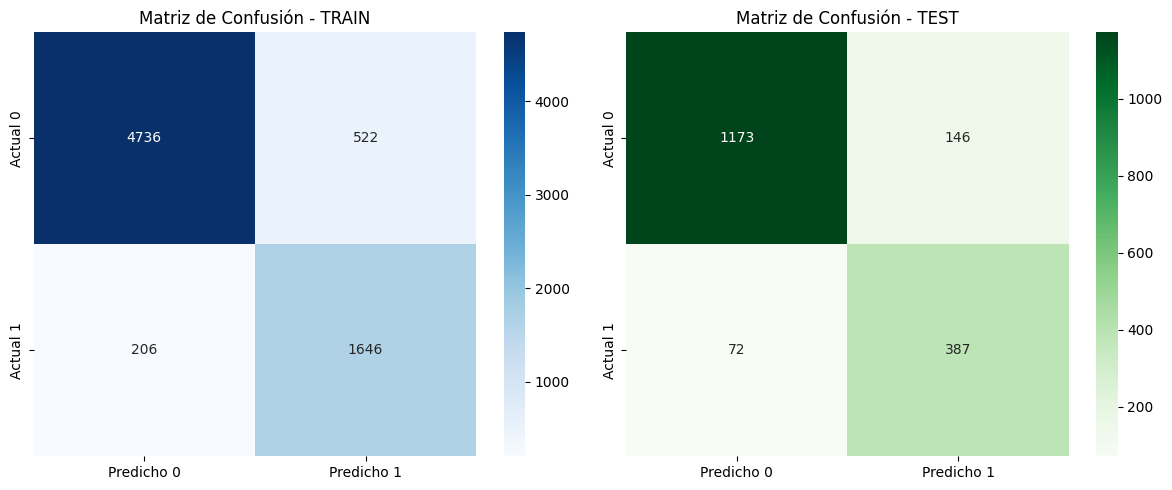

In [67]:
best_model = grid.best_estimator_

# Predicciones
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Reportes
print("Resultados en TRAIN:")
print(classification_report(y_train, y_pred_train))

print("\nResultados en TEST:")
print(classification_report(y_test, y_pred_test))

# Matriz de confusión para TRAIN
cm_train = confusion_matrix(y_train, y_pred_train)
cm_train_df = pd.DataFrame(
    cm_train,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicho 0', 'Predicho 1']
)

# Matriz de confusión para TEST
cm_test = confusion_matrix(y_test, y_pred_test)
cm_test_df = pd.DataFrame(
    cm_test,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicho 0', 'Predicho 1']
)

# Dibujar ambas en la misma fila
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_train_df, annot=True, cmap='Blues', fmt='g', ax=axes[0])
axes[0].set_title("Matriz de Confusión - TRAIN")

sns.heatmap(cm_test_df, annot=True, cmap='Greens', fmt='g', ax=axes[1])
axes[1].set_title("Matriz de Confusión - TEST")

plt.tight_layout()
plt.show()


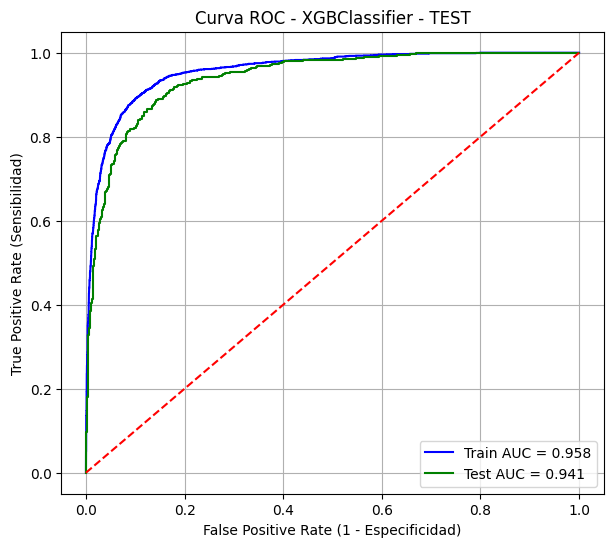

In [65]:
# Curva ROC para mejor modelo TEST

# Predicciones de probabilidad para la clase positiva (1)
y_train_proba = best_model.predict_proba(X_train)[:, 1]
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Curva ROC para TRAIN
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
roc_auc_train = roc_auc_score(y_train, y_train_proba)

# Curva ROC para TEST
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
roc_auc_test = roc_auc_score(y_test, y_test_proba)

# Graficar
label_fig = best_model_name + " - TEST"
plt.figure(figsize=(7, 6))
plt.plot(fpr_train, tpr_train, color='blue', label=f'Train AUC = {roc_auc_train:.3f}')
plt.plot(fpr_test, tpr_test, color='green', label=f'Test AUC = {roc_auc_test:.3f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea aleatoria
plt.xlabel('False Positive Rate (1 - Especificidad)')
plt.ylabel('True Positive Rate (Sensibilidad)')
plt.title('Curva ROC - ' + label_fig)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


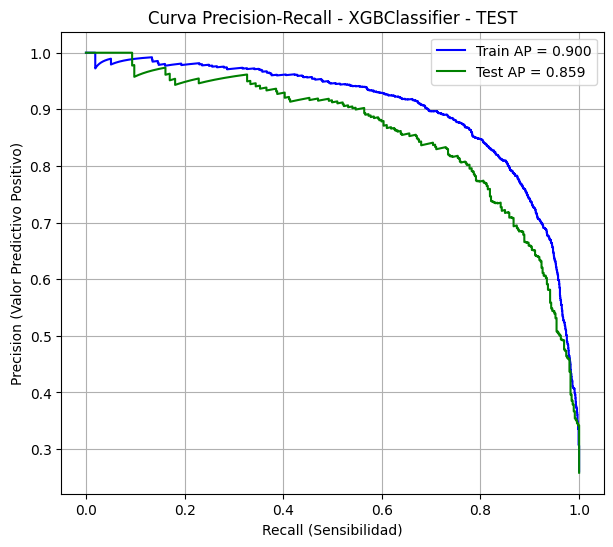

In [66]:
# Probabilidades para la clase positiva (1)
y_train_proba = best_model.predict_proba(X_train)[:, 1]
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Curva PR para TRAIN
precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_proba)
avg_prec_train = average_precision_score(y_train, y_train_proba)

# Curva PR para TEST
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)
avg_prec_test = average_precision_score(y_test, y_test_proba)

# Graficar
label_fig = best_model_name + " - TEST"
plt.figure(figsize=(7, 6))
plt.plot(recall_train, precision_train, color='blue', label=f'Train AP = {avg_prec_train:.3f}')
plt.plot(recall_test, precision_test, color='green', label=f'Test AP = {avg_prec_test:.3f}')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision (Valor Predictivo Positivo)')
plt.title('Curva Precision-Recall - ' + label_fig)
plt.legend(loc="upper right")
plt.grid(True)
plt.show()
